<h1><B>PERTANYAAN BISNIS</b></h1>
<p>1. Bagaimana sentimen pengguna terhadap layanan berdasarkan data kuesioner PKKMB, serta bagaimana hasil analisis tersebut dapat digunakan untuk meningkatkan kualitas layanan?</p>
<p>2. Apakah komentar panjang memiliki kecenderungan sentimen positif yang lebih tinggi dibanding komentar pendek berdasarkan hasil analisis sentimen feedback PKKMB</p>


<h1><B>IMPORT LIBRARY/PACKAGES YG DIGUNAKAN</b></h1>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import nltk
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.tokenize import word_tokenize
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from statsmodels.stats.proportion import proportions_ztest

<h1><B>DATA WRANGLING</b></h1>
<h2><B>GATHERING DATA</b></h2>
<h3>Load dan lihat data</h3>

In [2]:
df = pd.read_csv("Kuesioner_pkkmb.csv", sep=";")
df.head()

,Response,Submitted on:,Q16_KRITIK DAN SARAN,sentimen
0,345836,21/09/2025 01.06,Untuk servernya full dan error jadi agak susah...,negatif
1,306420,17/09/2025 23.02,Sudah baik untuk tahun ini namun akan lebih ba...,positif
2,341608,20/09/2025 18.47,Tolong perbaiki website PPKMB sehingga lebih m...,positif
3,293208,15/09/2025 20.21,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif
4,341272,20/09/2025 18.06,Semoga lebih baik,positif


<h2><B>ASSESSING DATA</b></h2>
<h3>Melihat informasi jumlah baris data, jumlah kolom, nilai non-null, dan data type </h3>


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13001 entries, 0 to 13000
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Response              13001 non-null  int64 
 1   Submitted on:         13001 non-null  object
 2   Q16_KRITIK DAN SARAN  12984 non-null  object
 3   sentimen              13001 non-null  object
dtypes: int64(1), object(3)
memory usage: 406.4+ KB


<h3>Mengecek missing value</h3>

In [4]:
df.isna().sum()

Response                 0
Submitted on:            0
Q16_KRITIK DAN SARAN    17
sentimen                 0
dtype: int64

<h3>Mengecek Jumlah label data</h3>

In [5]:
df['sentimen'].value_counts()

sentimen
positif    4722
netral     4642
negatif    3637
Name: count, dtype: int64

<h3>Mengecek data duplikat pada kolom kritik dan saran</h3>

In [6]:
df['Q16_KRITIK DAN SARAN'].duplicated().sum()

np.int64(4975)

<h2><B>CLEANING DATA</b></h2>
<h3>Mengganti nama kolom</h3>

In [7]:
df.rename(columns={
    'Q16_KRITIK DAN SARAN': 'Kritik dan saran',
    'sentimen': 'Sentimen',
    'Submitted on:': 'Submitted on'
}, inplace=True)

<h3>Menghapus nilai kosong</h3>

In [8]:
df = df.dropna(subset=['Kritik dan saran'])

<h3>Mengecek untuk memastikan tidak ada nilai kosong</h3>

In [9]:
df.isna().sum()

Response            0
Submitted on        0
Kritik dan saran    0
Sentimen            0
dtype: int64

<h3>Mengganti type object ke Datetime pada kolom submitted on</h3>

In [10]:
df['Submitted on'] = df['Submitted on'].str.replace('.', ':', regex=False)
df['Submitted on'] = pd.to_datetime(
    df['Submitted on'],
    format='%d/%m/%Y %H:%M'
)

<h3>Memastikan type object ke Datetime pada kolom submitted on sudah berubah</h3>

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12984 entries, 0 to 13000
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Response          12984 non-null  int64         
 1   Submitted on      12984 non-null  datetime64[ns]
 2   Kritik dan saran  12984 non-null  object        
 3   Sentimen          12984 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 507.2+ KB


<h3>Menghapus data duplikat</h3>

In [12]:
df.drop_duplicates(subset='Kritik dan saran', inplace=True)

<h3>Mengecek kembali jumlah data duplikat</h3>

In [13]:
df['Kritik dan saran'].duplicated().sum()

np.int64(0)

<h3>Mengecek Jumlah label setelah dihapus duplikat</h3>

In [14]:
df["Sentimen"].value_counts()

Sentimen
positif    4126
netral     2703
negatif    1196
Name: count, dtype: int64

<h1><B>EDA</b></h1>
<h2><B>EXPLORATORY DATA ANALYST</b></h2>
<h3><B>Melihat parameter statistik dari data</b></h3>

In [15]:
df.describe(include="all")

,Response,Submitted on,Kritik dan saran,Sentimen
count,8025.000000,8025,8025,8025
unique,NaN,NaN,8025,3
top,NaN,NaN,Untuk servernya full dan error jadi agak susah...,positif
freq,NaN,NaN,1,4126
mean,314293.974829,2025-09-17 20:37:49.016822272,NaN,NaN
min,275592.000000,2025-09-10 15:18:00,NaN,NaN
25%,294318.000000,2025-09-15 23:25:00,NaN,NaN
50%,312724.000000,2025-09-18 17:25:00,NaN,NaN
75%,334630.000000,2025-09-20 06:24:00,NaN,NaN
max,355214.000000,2025-09-22 10:40:00,NaN,NaN


<h3><B>Feature engineering waktu</b></h3>

In [16]:
df['Submitted on'] = pd.to_datetime(df['Submitted on'])
df['tanggal'] = df['Submitted on'].dt.date
df['jam'] = df['Submitted on'].dt.hour
df['hari'] = df['Submitted on'].dt.day_name()

<h3><B>Visualisasi jumlah feedback waktu pengisian PKKMB</b></h3>

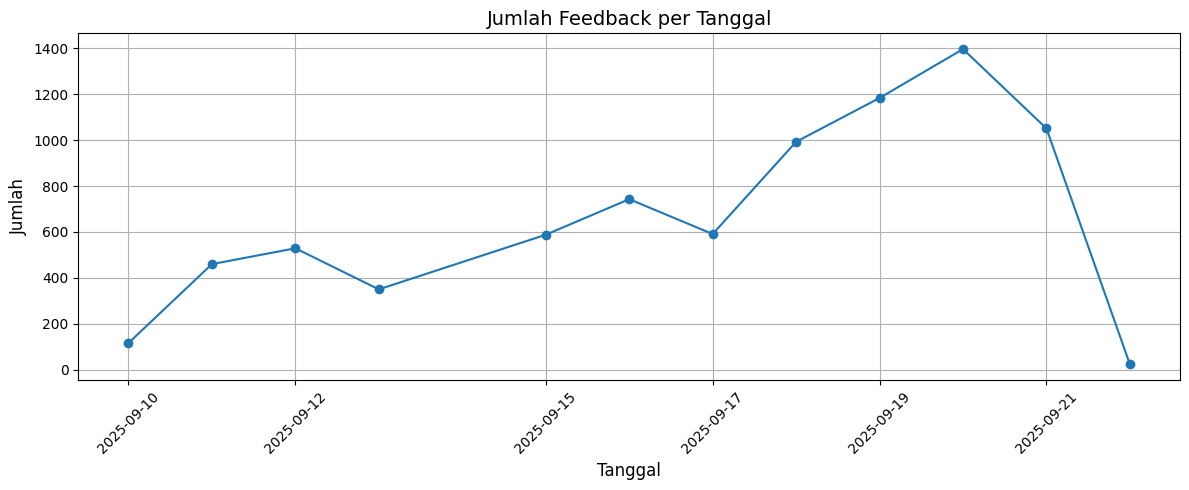

In [17]:

data_plot = df['tanggal'].value_counts().sort_index()

# Buat figure
plt.figure(figsize=(12,5))

# Plot line
plt.plot(data_plot.index, data_plot.values, marker='o')

# Judul & label
plt.title('Jumlah Feedback per Tanggal', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

# Rotasi tanggal biar gak numpuk
plt.xticks(data_plot.index[::2], rotation=45)  # tampilkan tiap 2 tanggal

# Grid biar enak dibaca
plt.grid()

# Layout biar tidak kepotong
plt.tight_layout()

# Tampilkan
plt.show()

<h3><B>Visualisasi persentase distribusi setiap sentimen</b></h3>

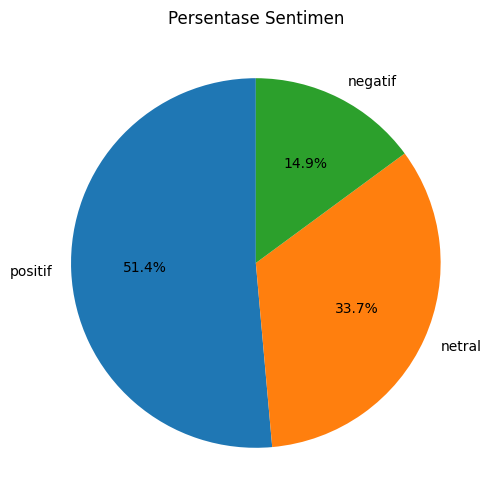

In [18]:
# Hitung jumlah tiap sentimen
sentiment_counts = df['Sentimen'].value_counts()

# Buat pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

# Judul chart
plt.title('Persentase Sentimen')

# Tampilkan chart
plt.show()

<h3><B>Visualisasi Jumlah dari setiap label sentimen</b></h3>

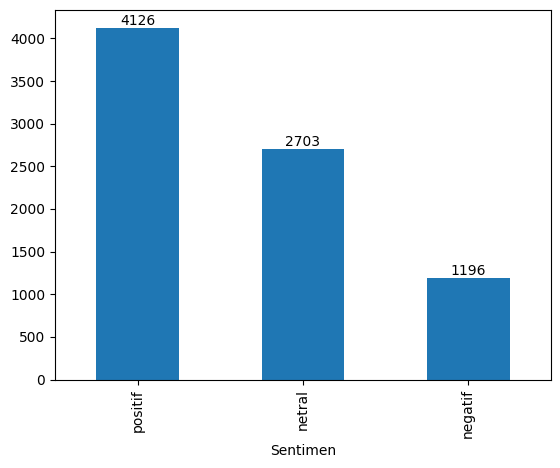

In [19]:
# Hitung jumlah sentimen
ax = df['Sentimen'].value_counts().plot(kind='bar')

# angka di atas bar
for p in ax.patches:
    ax.annotate(
        str(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

# Tampilkan chart
plt.show()

In [20]:
df['Sentimen'].value_counts()

Sentimen
positif    4126
netral     2703
negatif    1196
Name: count, dtype: int64

<h3><B>Analisis Frekuensi Kata</b></h3>

In [21]:
# Mengambil kolom komentar dan mengubah semua data menjadi string
corpus = df['Kritik dan saran'].astype(str)

# Inisialisasi CountVectorizer
# ngram_range=(1,2) -> menggunakan unigram dan bigram
# min_df=5 -> hanya mengambil kata yang muncul minimal 5 kali
count_vectorizer = CountVectorizer(
    ngram_range=(1,2),
    min_df=5
)

# Mengubah teks menjadi matriks frekuensi kata
count_matrix = count_vectorizer.fit_transform(corpus)

# Menjumlahkan seluruh frekuensi kata dari semua dokumen
word_counts = np.array(
    count_matrix.sum(axis=0)
).flatten()

# Membuat dataframe berisi:
# - kata/fitur
# - total frekuensi kemunculan
word_freq = pd.DataFrame({
    'kata': count_vectorizer.get_feature_names_out(),
    'frekuensi': word_counts
})

# Mengurutkan kata berdasarkan frekuensi tertinggi
word_freq = word_freq.sort_values(
    by='frekuensi',
    ascending=False
)

# Menampilkan 10 kata paling sering muncul
print(word_freq.head(10))

          kata  frekuensi
3451     pkkmb       4781
718        dan       4268
4897      yang       2836
2254     lebih       2508
4575     tidak       2495
4736     untuk       1955
1908  kegiatan       1895
1017        di       1870
3713    sangat       1819
3782      saya       1663


<h3><B>Visualisasi WordCloud sebelum preprocessing</b></h3>

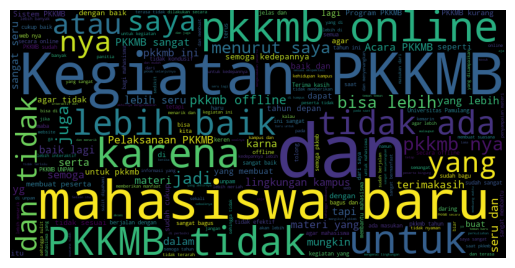

In [22]:
all_text = ' '.join(df['Kritik dan saran'].astype(str))
wc = WordCloud(width=800, height=400).generate(all_text)

plt.imshow(wc)
plt.axis('off')
plt.show()

<h1><B>PREPROCESSING DATA</b></h1>

In [23]:
!pip install Sastrawi


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h3><B>Text Preprocessing (Stemming & Stopword Removal)
</b></h3>

In [24]:
# Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Stopword
stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

<h3><B>Load data slang & Normalisasi Teks (Slang ke Kata Baku)
</b></h3>

In [25]:

# Load kamus normalisasi
kamus_df = pd.read_excel("Slangword-indonesian.xlsm")
kamus_normalisasi = dict(zip(kamus_df['slang'], kamus_df['formal']))

# Normalisasi langsung (tanpa function)
df['normalisasi'] = df['Kritik dan saran'].astype(str).apply(
    lambda teks: " ".join([kamus_normalisasi.get(kata, kata) for kata in teks.split()])
)

<h3><B>Melakukan Case Folding</b></h3>

In [26]:
df['case_folding'] = df['normalisasi'].astype(str).str.lower()
df['case_folding'] = df['case_folding'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

<h3><B>Mengunduh dataset/tokenizer untuk proses tokenisasi teks</b></h3>

In [27]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\fathu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\fathu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

<h3><B>Proses tokenizing</b></h3>



In [28]:
# Tokenizing
df['tokenizing'] = df['case_folding'].apply(lambda x: word_tokenize(x))
df.head()

,Response,Submitted on,Kritik dan saran,Sentimen,tanggal,jam,hari,normalisasi,case_folding,tokenizing
0,345836,2025-09-21 01:06:00,Untuk servernya full dan error jadi agak susah...,negatif,2025-09-21,1,Sunday,Untuk servernya full dan error jadi agak susah...,untuk servernya full dan error jadi agak susah...,"[untuk, servernya, full, dan, error, jadi, aga..."
1,306420,2025-09-17 23:02:00,Sudah baik untuk tahun ini namun akan lebih ba...,positif,2025-09-17,23,Wednesday,Sudah baik untuk tahun ini namun akan lebih ba...,sudah baik untuk tahun ini namun akan lebih ba...,"[sudah, baik, untuk, tahun, ini, namun, akan, ..."
2,341608,2025-09-20 18:47:00,Tolong perbaiki website PPKMB sehingga lebih m...,positif,2025-09-20,18,Saturday,Tolong perbaiki website PPKMB sehingga lebih m...,tolong perbaiki website ppkmb sehingga lebih m...,"[tolong, perbaiki, website, ppkmb, sehingga, l..."
3,293208,2025-09-15 20:21:00,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif,2025-09-15,20,Monday,Kegiatan PKKMB tahun ini menurut saya sudah be...,kegiatan pkkmb tahun ini menurut saya sudah be...,"[kegiatan, pkkmb, tahun, ini, menurut, saya, s..."
4,341272,2025-09-20 18:06:00,Semoga lebih baik,positif,2025-09-20,18,Saturday,Semoga lebih baik,semoga lebih baik,"[semoga, lebih, baik]"


<h3><B>Proses Filtering,stemming, dan clean review</b></h3>

In [29]:
# Filtering (hapus stopwords)
df['filtering'] = df['tokenizing'].apply(lambda tokens: [w for w in tokens if (w not in stopwords) or (w == "tidak")])
# stemming
df['stemming'] = df['filtering'].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)
# Gabungkan hasil stemming jadi kalimat akhir
df['clean_review'] = df['stemming'].apply(lambda tokens: " ".join(tokens))
df.tail(5)

,Response,Submitted on,Kritik dan saran,Sentimen,tanggal,jam,hari,normalisasi,case_folding,tokenizing,filtering,stemming,clean_review
12973,340744,2025-09-20 17:03:00,Pelaksanaan PKKMB tidak edukatif sehingga suli...,negatif,2025-09-20,17,Saturday,Pelaksanaan PKKMB tidak edukatif sehingga suli...,pelaksanaan pkkmb tidak edukatif sehingga suli...,"[pelaksanaan, pkkmb, tidak, edukatif, sehingga...","[pelaksanaan, pkkmb, tidak, edukatif, sulit, d...","[laksana, pkkmb, tidak, edukatif, sulit, paham]",laksana pkkmb tidak edukatif sulit paham
12974,340762,2025-09-20 17:05:00,Kegiatan PKKMB tidak komunikatif yang akhirnya...,negatif,2025-09-20,17,Saturday,Kegiatan PKKMB tidak komunikatif yang akhirnya...,kegiatan pkkmb tidak komunikatif yang akhirnya...,"[kegiatan, pkkmb, tidak, komunikatif, yang, ak...","[kegiatan, pkkmb, tidak, komunikatif, akhirnya...","[giat, pkkmb, tidak, komunikatif, akhir, kecew...",giat pkkmb tidak komunikatif akhir kecewa serta
12984,327624,2025-09-19 21:43:00,Program PKKMB sangat mengecewakan dan tidak se...,negatif,2025-09-19,21,Friday,Program PKKMB sangat mengecewakan dan tidak se...,program pkkmb sangat mengecewakan dan tidak se...,"[program, pkkmb, sangat, mengecewakan, dan, ti...","[program, pkkmb, sangat, mengecewakan, tidak, ...","[program, pkkmb, sangat, kecewa, tidak, sesuai...",program pkkmb sangat kecewa tidak sesuai ekspe...
12989,290826,2025-09-15 14:02:00,Pelaksanaan PKKMB tidak jelas sehingga membuan...,negatif,2025-09-15,14,Monday,Pelaksanaan PKKMB tidak jelas sehingga membuan...,pelaksanaan pkkmb tidak jelas sehingga membuan...,"[pelaksanaan, pkkmb, tidak, jelas, sehingga, m...","[pelaksanaan, pkkmb, tidak, jelas, membuang, w...","[laksana, pkkmb, tidak, jelas, buang, waktu]",laksana pkkmb tidak jelas buang waktu
12995,279478,2025-09-11 17:42:00,Pelaksanaan PKKMB tidak kondusif yang membuat ...,negatif,2025-09-11,17,Thursday,Pelaksanaan PKKMB tidak kondusif yang membuat ...,pelaksanaan pkkmb tidak kondusif yang membuat ...,"[pelaksanaan, pkkmb, tidak, kondusif, yang, me...","[pelaksanaan, pkkmb, tidak, kondusif, membuat,...","[laksana, pkkmb, tidak, kondusif, buat, serta,...",laksana pkkmb tidak kondusif buat serta bingung


<h3><B>Mapping sentimen ke sentimen biner</b></h3>

In [30]:
df['Sentimen_Biner'] = df['Sentimen'].map({
    'positif': 1,
    'negatif': -1,
    'netral': 0
})
df.head(5)

,Response,Submitted on,Kritik dan saran,Sentimen,tanggal,jam,hari,normalisasi,case_folding,tokenizing,filtering,stemming,clean_review,Sentimen_Biner
0,345836,2025-09-21 01:06:00,Untuk servernya full dan error jadi agak susah...,negatif,2025-09-21,1,Sunday,Untuk servernya full dan error jadi agak susah...,untuk servernya full dan error jadi agak susah...,"[untuk, servernya, full, dan, error, jadi, aga...","[servernya, full, error, jadi, susah, mengerja...","[servernya, full, error, jadi, susah, kerja]",servernya full error jadi susah kerja,-1
1,306420,2025-09-17 23:02:00,Sudah baik untuk tahun ini namun akan lebih ba...,positif,2025-09-17,23,Wednesday,Sudah baik untuk tahun ini namun akan lebih ba...,sudah baik untuk tahun ini namun akan lebih ba...,"[sudah, baik, untuk, tahun, ini, namun, akan, ...","[baik, tahun, lebih, baik, laksanakan, langsun...","[baik, tahun, lebih, baik, laksana, langsung, ...",baik tahun lebih baik laksana langsung terima ...,1
2,341608,2025-09-20 18:47:00,Tolong perbaiki website PPKMB sehingga lebih m...,positif,2025-09-20,18,Saturday,Tolong perbaiki website PPKMB sehingga lebih m...,tolong perbaiki website ppkmb sehingga lebih m...,"[tolong, perbaiki, website, ppkmb, sehingga, l...","[perbaiki, website, ppkmb, lebih, mudah, cepat...","[baik, website, ppkmb, lebih, mudah, cepat, ak...",baik website ppkmb lebih mudah cepat akses,1
3,293208,2025-09-15 20:21:00,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif,2025-09-15,20,Monday,Kegiatan PKKMB tahun ini menurut saya sudah be...,kegiatan pkkmb tahun ini menurut saya sudah be...,"[kegiatan, pkkmb, tahun, ini, menurut, saya, s...","[kegiatan, pkkmb, tahun, berjalan, baik, membe...","[giat, pkkmb, tahun, jalan, baik, beri, banyak...",giat pkkmb tahun jalan baik beri banyak inform...,1
4,341272,2025-09-20 18:06:00,Semoga lebih baik,positif,2025-09-20,18,Saturday,Semoga lebih baik,semoga lebih baik,"[semoga, lebih, baik]","[semoga, lebih, baik]","[moga, lebih, baik]",moga lebih baik,1


<h3>Mengubah teks komentar/review menjadi data numerik menggunakan metode TF-IDF</h3>

In [31]:

# Ambil teks bersih
corpus = df['clean_review'].astype(str)

# Inisialisasi TF-IDF (unigram + bigram supaya lebih kaya fitur)
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=5)

# Fit dan transform
tfidf_matrix = vectorizer.fit_transform(corpus)

# Cek ukuran matrix
print("TF-IDF matrix shape:", tfidf_matrix.shape)

# Lihat 20 fitur pertama
print(vectorizer.get_feature_names_out()[:10])

TF-IDF matrix shape: (8025, 3327)
['aamiin' 'absen' 'absensi' 'ac' 'ac kurang' 'ac nya' 'acara' 'acara baik'
 'acara buat' 'acara jalan']


<h3>Visualisasi WordCloud setelah preprocessing</h3>

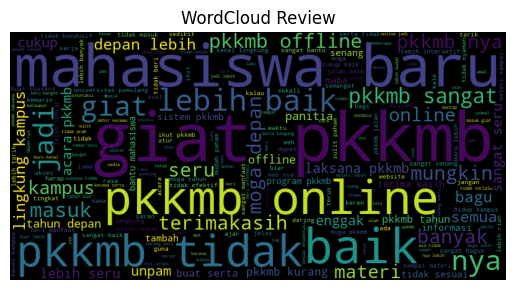

In [32]:
text = " ".join(df['clean_review'].astype(str))

# Buat WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='viridis',
    max_words=200
).generate(text)

# Tampilan
plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud Review")
plt.show()

<h3>Visualisasi WordCloud dari seluruh kolom clean_review berlabel positif</h3>

Text(0.5, 1.0, 'WordCloud Sentimen Positif')

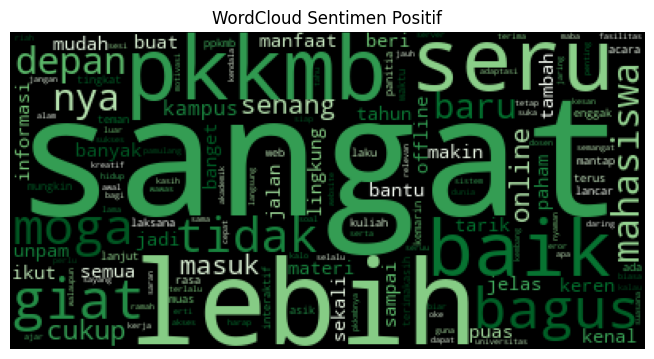

In [33]:
# Positif
vectorizer_pos = TfidfVectorizer(max_features=500)
tfidf_pos = vectorizer_pos.fit_transform(df[df['Sentimen']=='positif']['clean_review'].astype(str))

scores_pos = dict(zip(vectorizer_pos.get_feature_names_out(), tfidf_pos.sum(axis=0).A1))

# WordCloud
wc_pos = WordCloud(background_color='black', colormap='Greens').generate_from_frequencies(scores_pos)
# Plot
plt.figure(figsize=(18,8))

plt.subplot(1,2,1)
plt.imshow(wc_pos)
plt.axis('off')
plt.title("WordCloud Sentimen Positif")

<h3>Visualisasi WordCloud dari seluruh kolom clean_review berlabel negatif</h3>

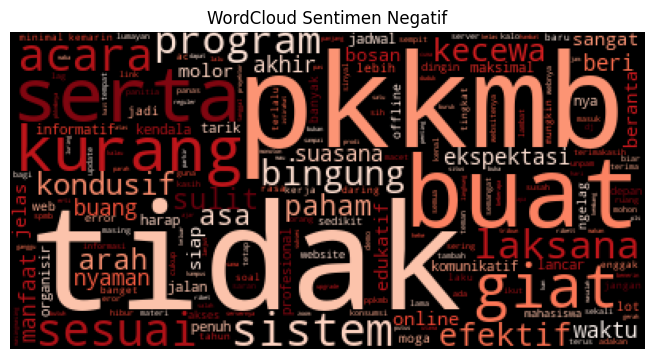

In [34]:
# Negatif
vectorizer_neg = TfidfVectorizer(max_features=500)
tfidf_neg = vectorizer_neg.fit_transform(df[df['Sentimen']=='negatif']['clean_review'].astype(str))

scores_neg = dict(zip(vectorizer_neg.get_feature_names_out(), tfidf_neg.sum(axis=0).A1))

wc_neg = WordCloud(background_color='black', colormap='Reds').generate_from_frequencies(scores_neg)

# Plot
plt.figure(figsize=(18,8))
plt.subplot(1,2,2)
plt.imshow(wc_neg)
plt.axis('off')
plt.title("WordCloud Sentimen Negatif")

plt.show()

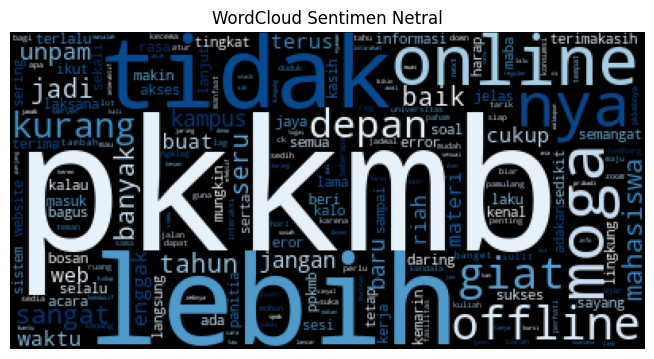

In [45]:
# Netral
vectorizer_net = TfidfVectorizer(max_features=500)
tfidf_net = vectorizer_net.fit_transform(df[df['Sentimen']=='netral']['clean_review'].astype(str))

scores_net = dict(zip(vectorizer_net.get_feature_names_out(), tfidf_net.sum(axis=0).A1))

wc_net = WordCloud(background_color='black', colormap='Blues').generate_from_frequencies(scores_net)

# Plot
plt.figure(figsize=(18,8))
plt.subplot(1,2,2)
plt.imshow(wc_net)
plt.axis('off')
plt.title("WordCloud Sentimen Netral")

plt.show()

## A/B TESTING Komentar Pendek vs Panjang menggunakan uji statistik Z-test

In [35]:
# GROUP A = komentar pendek
group_a = df[df['Kritik dan saran'].astype(str).apply(len) < 50]

# GROUP B = komentar panjang
group_b = df[df['Kritik dan saran'].astype(str).apply(len) >= 50]

# HITUNG SENTIMEN POSITIF
positive_a = (group_a['Sentimen'] == 'positif').sum()
positive_b = (group_b['Sentimen'] == 'positif').sum()

# TOTAL DATA
total_a = len(group_a)
total_b = len(group_b)

### Menggunakan A/B Testing Z-Test

In [36]:
# A/B TESTING (Z-Test)
success = [positive_a, positive_b]
total = [total_a, total_b]
z_stat, p_value = proportions_ztest(success, total)

### Menampilkan hasil dari A/B testing Z-test

In [37]:
# HASIL A/B TESTING
print("=== HASIL A/B TESTING ===\n")

print("Komentar Pendek")
print("Total Data :", total_a)
print("Sentimen Positif :", positive_a)

print("\nKomentar Panjang")
print("Total Data :", total_b)
print("Sentimen Positif :", positive_b)

print("\nZ-Statistic :", round(z_stat, 4))
print("P-Value :", format(p_value, '.13f'))

# Interpretasi
alpha = 0.05

if p_value < alpha:
    print("\nAda perbedaan signifikan")
else:
    print("\nTidak ada perbedaan signifikan")

=== HASIL A/B TESTING ===

Komentar Pendek
Total Data : 2616
Sentimen Positif : 1480

Komentar Panjang
Total Data : 5409
Sentimen Positif : 2646

Z-Statistic : 6.4326
P-Value : 0.0000000001254

Ada perbedaan signifikan


###  Visualisasi A/B testing persentase sentimen positif antara komentar pendek dan panjang

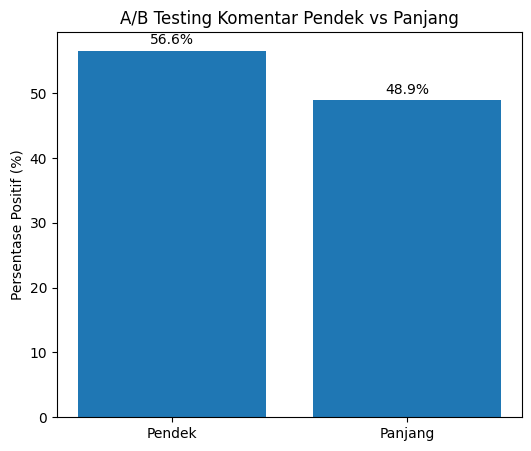

In [38]:
# VISUALISASI
positive_rates = [
    positive_a / total_a * 100,
    positive_b / total_b * 100
]

groups = ['Pendek', 'Panjang']

plt.figure(figsize=(6,5))
bars = plt.bar(groups, positive_rates)
plt.ylabel('Persentase Positif (%)')
plt.title('A/B Testing Komentar Pendek vs Panjang')

# Tambah angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1,
        f'{yval:.1f}%',
        ha='center'
    )
plt.show()

# JAWABAN PERTANYAAN BISNIS

## 1. Analisis Sentimen terhadap Layanan PKKMB

Berdasarkan hasil analisis sentimen terhadap **8025 data kuesioner PKKMB**, diperoleh:

- **4126 sentimen positif (51,4%)**
- **2703 sentimen netral (33,7%)**
- **1196 sentimen negatif (14,9%)**

Hasil tersebut menunjukkan bahwa mayoritas peserta memberikan tanggapan positif terhadap pelaksanaan PKKMB.

### Analisis WordCloud Review

Dari hasil **WordCloud Review**, kata yang paling sering muncul antara lain:

- *“baik”*
- *“seru”*
- *“terimakasih”*
- *“offline”*

Kata-kata tersebut menunjukkan bahwa banyak peserta merasa kegiatan PKKMB berjalan dengan baik, menarik, dan lebih nyaman ketika dilakukan secara offline. Selain itu, muncul juga kata seperti *“mahasiswa baru”* dan *“panitia”*, yang menandakan bahwa interaksi antara peserta dan panitia menjadi bagian penting dalam pengalaman peserta selama kegiatan berlangsung.

### Analisis Sentimen Negatif

Pada **WordCloud Sentimen Negatif**, terlihat beberapa kata dominan seperti:

- *“tidak”*
- *“kurang”*
- *“bingung”*
- *“molor”*
- *“sulit”*
- *“kecewa”*
- *“bosan”*
- *“online”*

Hal ini menunjukkan bahwa sebagian peserta masih mengalami kendala selama kegiatan berlangsung, seperti:

- Informasi yang kurang jelas
- Komunikasi yang belum efektif
- Jadwal kegiatan yang molor
- Suasana kegiatan yang kurang kondusif
- Pelaksanaan kegiatan online yang kurang menarik
- Kesulitan memahami materi

Selain itu, munculnya kata *“bingung”* dan *“arah”* mengindikasikan bahwa masih terdapat peserta yang merasa kurang mendapatkan arahan yang jelas selama kegiatan PKKMB berlangsung.

### Bahan evaluasi

Hasil analisis ini dapat dijadikan bahan evaluasi untuk meningkatkan kualitas layanan PKKMB, terutama pada aspek:

- Komunikasi informasi
- Pengelolaan jadwal kegiatan
- Efektivitas penyampaian materi
- Interaktivitas kegiatan
- Kejelasan arahan kepada peserta

Dengan melakukan perbaikan pada aspek tersebut, diharapkan kualitas pelaksanaan PKKMB di masa mendatang dapat menjadi lebih baik dan meningkatkan kepuasan peserta.
## 2. Apakah Komentar Panjang Memiliki Kecenderungan Sentimen Positif yang Lebih Tinggi Dibanding Komentar Pendek?

Berdasarkan hasil analisis sentimen terhadap feedback PKKMB, diperoleh data sebagai berikut:

### Komentar Pendek
- **Total data:** 2616
- **Sentimen positif:** 1480

### Komentar Panjang
- **Total data:** 5409
- **Sentimen positif:** 2646

Hasil uji statistik menunjukkan:

- **Z-Statistic:** 6.4326
- **P-Value:** 0.0000000001254

Nilai **P-Value** yang sangat kecil (lebih kecil dari 0,05) menunjukkan bahwa terdapat perbedaan yang signifikan antara komentar pendek dan komentar panjang terhadap jumlah sentimen positif.

Meskipun jumlah sentimen positif pada komentar panjang lebih banyak secara total, proporsi sentimen positif pada komentar pendek cenderung lebih tinggi dibandingkan komentar panjang. Hal ini menunjukkan bahwa komentar pendek lebih sering berisi tanggapan singkat yang langsung mengandung apresiasi, seperti *“bagus”*, *“seru”*, atau *“baik”*.

Sementara itu, komentar panjang biasanya berisi penjelasan yang lebih detail, kritik, maupun saran terhadap pelaksanaan PKKMB. Oleh karena itu, komentar panjang tidak selalu didominasi oleh sentimen positif karena peserta cenderung menjelaskan pengalaman mereka secara lebih mendalam.

Hasil analisis ini menunjukkan bahwa panjang komentar memiliki hubungan terhadap pola sentimen peserta dan dapat digunakan sebagai bahan evaluasi untuk memahami kepuasan maupun kritik peserta secara lebih detail.

### Melihat hasil processing data dari jumlah baris data, jumlah kolom, dan lain-lain untuk memastikan data siap di proses oleh model

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8025 entries, 0 to 12995
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Response          8025 non-null   int64         
 1   Submitted on      8025 non-null   datetime64[ns]
 2   Kritik dan saran  8025 non-null   object        
 3   Sentimen          8025 non-null   object        
 4   tanggal           8025 non-null   object        
 5   jam               8025 non-null   int32         
 6   hari              8025 non-null   object        
 7   normalisasi       8025 non-null   object        
 8   case_folding      8025 non-null   object        
 9   tokenizing        8025 non-null   object        
 10  filtering         8025 non-null   object        
 11  stemming          8025 non-null   object        
 12  clean_review      8025 non-null   object        
 13  Sentimen_Biner    8025 non-null   int64         
dtypes: datetime64[ns](1), int32(

### Menyimpan data ke CSV untuk lanjut ke tahap pembuatan Model

In [40]:
df.to_csv('Sentimen_Cleaned.csv', index=False)